# Fine-tuning Stable Diffusion Model

## Packages

In [1]:
import torch
import math
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import pandas as pd
from torchvision import transforms
import os
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from tqdm.auto import tqdm
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import set_seed
import bitsandbytes as bnb
import torch.nn.functional as F
import logging, sys
import itertools
import json
import numpy as np


c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\transformers\transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


## Parameters

In [2]:
check_point = r'C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-1000'

base_model_name = check_point #'stabilityai/sd-turbo'

image_desc_file = r'C:\COMP9800\Dataset\kvasir-dataset\image_description_partial.csv'
image_data_root = r'C:\COMP9800\Dataset\kvasir-dataset'

diagram_caption_file = r"C:\COMP9800\Dataset\AI2D-Caption\ai2d_caption_gpt4v.json"
diagram_image_root= r"C:\COMP9800\Dataset\AI2D-Caption\ai2d_images"

compressor_chpt = r"C:\COMP9800\model_checkpoints\compressor\compressor_weight_400E.pt"


## Hyperparameters

In [3]:
device = 'cpu'
learning_rate = 0.00005
train_batch_size = 8
lr_scheduler_type = 'cosine'
lr_warmup_steps=100
gradient_accumulation_steps = 2
max_train_steps =400
train_text_encoder = False
train_batch_size = 2
output_dir='fine_tuned_models'
mixed_precision = 'fp16'
max_grad_norm = 1
save_steps = 500
max_text_token_size = 300


## Define Dataset Classes

In [4]:
class KvasirDataset(Dataset):
    def __init__(self,image_desc_file, image_data_root, tokenizer, img_size):
        # self.image_desc_file = image_desc_file
        self.image_data_root = image_data_root
        self.tokenizer = tokenizer
        self.image_size = img_size
        self.image_desc_data = pd.read_csv(image_desc_file)
        self.len = len(self.image_desc_data)
        self.transforms = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.CenterCrop(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])
        
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        row = self.image_desc_data.iloc[idx]
        image_path = os.path.join(self.image_data_root, row.iloc[0], row.iloc[1])
        image = Image.open(image_path).convert('RGB')
        # print(image.size)
        image = self.transforms(image)

        desc_tokens = self.tokenizer(row.iloc[2],
                                     padding='max_length',
                                     truncation=True,
                                     max_length=self.tokenizer.model_max_length,
                                     return_tensors='pt'
                                    )
        desc_ids = desc_tokens.input_ids.squeeze(0)
        return {'images': image, 'prompt_ids': desc_ids}
    


In [5]:
class DiagramDataset(Dataset):
    def __init__(self, caption_data, image_data_root, tokenizer, img_size):
        self.image_captions = self.load_captions(caption_data)
        self.image_data_root = image_data_root
        self.tokenizer = tokenizer
        self.image_size = img_size
        self.len = len(self.image_captions)
        self.transforms = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.CenterCrop(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])


    def load_captions(self, caption_file):
        with open(caption_file,'r') as f:
            captions = json.load(f)
        image_captions=[]
        for cap in captions:
            if 'caption' not in cap:
                continue
            image_captions.append({'img':cap['image'], 'caption':cap['caption']})
        
        return image_captions
    
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        img_cap = self.image_captions[idx]
        image_path = os.path.join(self.image_data_root, img_cap['img'])
        image = Image.open(image_path).convert('RGB')
        # print(image.size)
        image = self.transforms(image)

        desc_tokens = self.tokenizer(img_cap['caption'],
                                     padding='max_length',
                                     truncation=True,
                                     max_length=self.tokenizer.model_max_length,
                                     return_tensors='pt'
                                    )
        desc_ids = desc_tokens.input_ids.squeeze(0)
        return {'images': image, 'prompt_ids': desc_ids}

In [6]:
# from huggingface_hub import login
# login

## Load Pretrained Model stabilityai/sd-turbo

In [7]:
tokenizer = CLIPTokenizer.from_pretrained(
    base_model_name,
    subfolder="tokenizer",
)

vae = AutoencoderKL.from_pretrained(
    base_model_name, subfolder="vae"
)

text_encoder = CLIPTextModel.from_pretrained(
    base_model_name, subfolder="text_encoder"
)

unet = UNet2DConditionModel.from_pretrained(
    base_model_name, subfolder="unet"
)

noise_scheduler = DDPMScheduler.from_config(base_model_name, subfolder="scheduler")
print(f'【{base_model_name}】 is now loaded.')


【C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-1000】 is now loaded.


c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\configuration_utils.py:245: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


## Load Dataset

In [8]:
def collate_fn(examples):
    input_ids = [example["prompt_ids"] for example in examples]
    pixel_values = [example["images"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    input_ids = tokenizer.pad(
        {"input_ids": input_ids},
        padding="max_length",
        return_tensors="pt",
        max_length=tokenizer.model_max_length
    ).input_ids

    batch = {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }
    return batch

In [9]:
print('Sample Size in VAE:', vae.sample_size)

colon_ds = KvasirDataset(image_desc_file, image_data_root, tokenizer, vae.sample_size)

colon_train_dataloader = DataLoader(
    colon_ds, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn
)



diagram_ds = DiagramDataset(diagram_caption_file,
                            diagram_image_root, 
                            tokenizer, vae.sample_size)

diagram_train_dataloader = DataLoader(
    diagram_ds, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn
)

print('Dataloaders are ready.')

C:\Users\50183\AppData\Local\Temp\ipykernel_29372\1491477756.py:1: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_size'.
  print('Sample Size in VAE:', vae.sample_size)
C:\Users\50183\AppData\Local\Temp\ipykernel_29372\1491477756.py:3: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_size'.
  colon_ds = KvasirDataset(image_desc_file, image_data_root, tokenizer, vae.sample_size)
C:\Users\50183\AppData\Local\Temp\ipykernel_29372\1491477756.py:13: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_si

Sample Size in VAE: 768
Dataloaders are ready.


## Define Models

In [10]:
class TokenCompressor(nn.Module):
    def __init__(self, input_len, vocab_size , target_len=77, embed_dim=1024):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(input_len, embed_dim)
        self.proj = nn.Linear(input_len, target_len, bias=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.register_buffer(
            "position_ids", torch.arange(input_len).expand((1, -1)), persistent=False
        )

    def forward(self, input_ids):
        seq_length = input_ids.shape[-1] if input_ids is not None else inputs_embeds.shape[-2]
        position_ids = self.position_ids[:, :seq_length]
        inputs_embeds = self.token_embedding(input_ids)

        position_embeddings = self.position_embedding(position_ids)
        embeddings = inputs_embeds + position_embeddings
        # x shape: (batch, input_len, embed_dim)
        input_ids = embeddings.transpose(1, 2)  # (batch, embed_dim, input_len)
        input_ids = self.proj(input_ids)       # (batch, embed_dim, target_len)
        input_ids = input_ids.transpose(1, 2)  # (batch, target_len, embed_dim)
        return self.norm(input_ids)


In [11]:
class MedQATTIModel(nn.Module):
    def __init__(self, tokenizer,
                 vae, text_encoder, 
                 unet, noise_scheduler, 
                 weight_dtype, train_text_encoder,
                #  scheduler,
                 text_compressor):
        super().__init__()
        
        self.tokenizer = tokenizer
        self.vae = vae
        self.text_encoder = text_encoder
        self.unet = unet
        self.noise_scheduler = noise_scheduler
        self.weight_dtype = weight_dtype
        # self.scheduler = scheduler
        self.text_compressor = text_compressor
        self.text_compressor.eval()

        self.vae.eval() #freeze
        self.vae.requires_grad_(False)
        if not train_text_encoder: 
            self.text_encoder.eval() #freeze
            self.text_encoder.requires_grad_(False)
        else:
            self.text_encoder.gradient_checkpointing_enable()
        self.unet.enable_gradient_checkpointing()

    def forward(self, batch):
        latents = self.vae.encode(batch["pixel_values"].to(dtype=self.weight_dtype)).latent_dist.sample()
        latents = latents * 0.18215 #Normalize Latent for unet

        # Sample noise
        noise = torch.randn_like(latents)
        batch_size = latents.shape[0]
        # Sample a random timestep for each image
        timesteps = torch.randint(0, 
                                  self.noise_scheduler.config.num_train_timesteps, 
                                  (batch_size,), 
                                  device=latents.device)
        timesteps = timesteps.long()

        # Add noise to the latents, forward process of diffusion
        noisy_latents = self.noise_scheduler.add_noise(latents, noise, timesteps)

        # Get the text embedding for conditioning
        encoder_hidden_states = self.text_encoder(batch["input_ids"])[0]
        
        # Predict the noise residual
        noise_pred = self.unet(noisy_latents, timesteps, encoder_hidden_states).sample

        if self.noise_scheduler.config.prediction_type == "epsilon":
            target = noise
        elif self.noise_scheduler.config.prediction_type == "v_prediction":
            target = noise_scheduler.get_velocity(latents, noise, timesteps)
            
        return noise_pred , target
    
    @torch.no_grad()
    def infer(self,prompt, inference_steps=50, guidance_scale=7.5):
        prompt_tokens = self.tokenizer(prompt, max_length=max_text_token_size, 
                                       padding='max_length', 
                                       truncation=True, 
                                       return_tensors='pt').input_ids
        if prompt_tokens.shape[1] > 77:
            embeddings = self.text_compressor(prompt_tokens)
            print('Prompt is compressed to fit the Unet.')
        else:
            embeddings = self.text_encoder(prompt_tokens)[0]
        
        embeddings.to(device, dtype=self.unet.dtype)

        # negative_embeddings = torch.zeros_like(embeddings)
        encoder_hidden_states = embeddings #torch.cat([negative_embeddings, embeddings], dim=0)

        batch_size = prompt_tokens.shape[0]
        latents = torch.randn(
                            (batch_size, self.unet.in_channels, 64, 64),
                            device=device,
                            dtype=self.unet.dtype
                            )
        self.noise_scheduler.set_timesteps(inference_steps)
        
        for t in tqdm(self.noise_scheduler.timesteps):
            latent_input = latents #torch.cat([latents] * 2, dim=0)

            noise_pred = self.unet(
                latent_input,
                t,
                encoder_hidden_states=encoder_hidden_states,
                return_dict=False,
            )[0]

            # classifier-free guidance
            # noise_uncond, noise_text = noise_pred.chunk(2)
            # noise_pred = noise_uncond + guidance_scale * (noise_text - noise_uncond)

            latents = self.noise_scheduler.step(noise_pred, t, latents, return_dict=False)[0]

        # -------- 6. Decode --------
        latents = latents / 0.18215
        image = self.vae.decode(latents, return_dict=False, )[0]

        return image

## Training Code

In [12]:
class EarlyStop:
    def __init__(self, max_iter):
        self.max_iteration = max_iter
        self.best_loss = None
        self.counter = 0
        self.need_stop = False
        self.loss_history=[]

    def step(self, val_loss):
        self.loss_history.append(val_loss)
        if self.best_loss is None:
            self.best_loss = val_loss
        elif self.best_loss > val_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.max_iteration:
                self.need_stop = True
        

In [13]:
def training_function(text_encoder, vae, unet, train_dataloader):
    loss_hist = []
    set_seed(27)
    accelerator = Accelerator(
        gradient_accumulation_steps=gradient_accumulation_steps,
        mixed_precision=mixed_precision,
        # cpu_offload=True,
    )
    print('Available Device:',accelerator.device)
    device = accelerator.device

    # Use 8-bit Adam for lower memory usage or to fine-tune the model in 16GB GPUs
    if accelerator.device.type == 'cuda':
        optimizer_class = bnb.optim.AdamW8bit
    else:
        optimizer_class = torch.optim.AdamW

    params_to_optimize = (
        itertools.chain(unet.parameters(), text_encoder.parameters()) if train_text_encoder else unet.parameters()
    )

    optimizer = optimizer_class(
        params_to_optimize,
        lr=learning_rate,
    )
    
    lr_scheduler = get_scheduler(
        lr_scheduler_type,
        optimizer=optimizer,
        num_warmup_steps=lr_warmup_steps * gradient_accumulation_steps,
        num_training_steps=max_train_steps * gradient_accumulation_steps,
    )
    
    # print(lr_scheduler)
    # lr_hist = []
    # for i in range(300):
    #     lr_hist.append(lr_scheduler.get_last_lr())
    #     print(lr_scheduler.get_last_lr())
    #     lr_scheduler.step()
    # return lr_hist

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # We need to recalculate our total training steps as the size of the training dataloader may have changed.
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
    num_train_epochs = math.ceil(max_train_steps / num_update_steps_per_epoch)
    
    total_batch_size = train_batch_size * accelerator.num_processes * gradient_accumulation_steps
    
    print("total btach size:",total_batch_size)
    print("***** Running training *****")
    print(f"  Instantaneous batch size per device = {train_batch_size}")
    print(f"  Total train batch size (w. parallel, distributed & accumulation) = {total_batch_size}")
    print(f"  Gradient Accumulation steps = {gradient_accumulation_steps}")
    print(f"  Total optimization steps = {max_train_steps}")
    # Only show the progress bar once on each machine.
    progress_bar = tqdm(range(max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")

    global_step = 0

    early_stopping = EarlyStop(max_iter=10000)


    comp_state_dict = torch.load(compressor_chpt, map_location=device)

    token_vocab_size = text_encoder.config.vocab_size #CLIPTextModel
    compressor = TokenCompressor(max_text_token_size, token_vocab_size)

    compressor.load_state_dict(comp_state_dict)
    compressor.eval()
    compressor.to('cpu') #

    unet.to(memory_format=torch.channels_last)
    
    model = MedQATTIModel(tokenizer,vae, text_encoder, unet, 
                          noise_scheduler, weight_dtype, 
                          train_text_encoder, compressor)
    
    model.to(accelerator.device)

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(model, 
                                                                           optimizer, 
                                                                           train_dataloader, 
                                                                           lr_scheduler)
    model.train()
    for epoch in range(num_train_epochs):
        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(unet):
                noise_pred, target = model(batch)
                loss = F.mse_loss(noise_pred.float(), target.float(), reduction="mean")
                accelerator.backward(loss)
                early_stopping.step(loss.detach().item())
                if early_stopping.need_stop:
                    print("Early stopping triggered")
                    break

                if accelerator.sync_gradients:
                    params_to_clip = (
                        itertools.chain(unet.parameters(), text_encoder.parameters())
                        if train_text_encoder
                        else unet.parameters()
                    )
                    accelerator.clip_grad_norm_(params_to_clip, max_grad_norm)
                optimizer.step()
                # print(optimizer.param_groups[0]['lr'])
                optimizer.zero_grad()
                lr_scheduler.step()

            # Checks if the accelerator has performed an optimization step behind the scenes
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                if global_step % save_steps == 0:
                    if accelerator.is_main_process:
                        unwrapped_unet = accelerator.unwrap_model(model.unet)
                        save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
                        accelerator.save(unwrapped_unet.state_dict(), save_path)
                        print(f'checkpoint {global_step} saved.')
                if global_step % 10 == 0:
                    print(f'Training Progress: {global_step} / {max_train_steps}',' Avg. Loss:', np.mean(loss_hist))
            logs = {"loss": loss.detach().item()}
            loss_hist.append(logs['loss'])
            progress_bar.set_postfix(**logs)

            if global_step >= max_train_steps:
                break
        del noise_pred, target
        torch.cuda.empty_cache()
        
        accelerator.wait_for_everyone()

    # Create the pipeline using using the trained modules and save it.
    if accelerator.is_main_process:
        unwrapped_unet = accelerator.unwrap_model(model.unet)
        save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
        accelerator.save(unwrapped_unet.state_dict(), save_path)
        print(f'checkpoint {global_step} saved.')
    
    return loss_hist

In [14]:
loss_hist = training_function(text_encoder, vae, unet, diagram_train_dataloader)

Available Device: cpu
total btach size: 4
***** Running training *****
  Instantaneous batch size per device = 2
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 2
  Total optimization steps = 400


  0%|          | 0/400 [00:00<?, ?it/s]

RuntimeError: Input type (struct c10::Half) and bias type (float) should be the same

In [15]:
# Free up some memory after training
for param in itertools.chain(unet.parameters(), text_encoder.parameters()):
    if param.grad is not None:
        del param.grad  # Free some memory
    torch.cuda.empty_cache()  # Empty the CUDA cache

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_hist, label="Training Loss", color="blue", linewidth=2)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)

plt.savefig('loss_curver.png', dpi=600)

plt.show()

NameError: name 'loss_hist' is not defined

<Figure size 800x500 with 0 Axes>

## Evaluate

In [17]:
import torch
from diffusers import AutoPipelineForText2Image
check_point = r'C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-1000'
pipe = AutoPipelineForText2Image.from_pretrained(check_point, torch_dtype=torch.float32)
pipe = pipe.to('cpu')

c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\vq_model.py:20: FutureWarning: `VQEncoderOutput` is deprecated and will be removed in version 0.31. Importing `VQEncoderOutput` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQEncoderOutput`, instead.
  deprecate("VQEncoderOutput", "0.31", deprecation_message)
c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\vq_model.py:25: FutureWarning: `VQModel` is deprecated and will be removed in version 0.31. Importing `VQModel` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQModel`, instead.
  deprecate("VQModel", "0.31", deprecation_message)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [18]:
state_dict_diag_unet = torch.load(r"C:\Users\50183\Downloads\checkpoint-1469 (1).pt", map_location='cpu')
pipe.unet.load_state_dict(state_dict_diag_unet)

<All keys matched successfully>

In [19]:
# prompt='an endoscopic image of dyed resection margins shows a close - up view of a surgical site within the gastrointestinal tract, likely the stomach or duodenum. the resection margins are dyed in a specific color, which appears to be a shade of blue.'
prompt='An endoscopic image of polyps typically shows the polyps on the mucosa of the gastrointestinal tract. The polyps appears as small, reddish-brown or yellowish-brown growths. ' \
'The surrounding mucosa is a lighter shade of red, and the surface texture of the polyps can be slightly rough.'
prompt = 'A diagram showing Earth''s position in relation to the Sun during different seasons and equinoxes.'
prompt = 'A diagram showing software development life cycle.'

  0%|          | 0/50 [00:00<?, ?it/s]

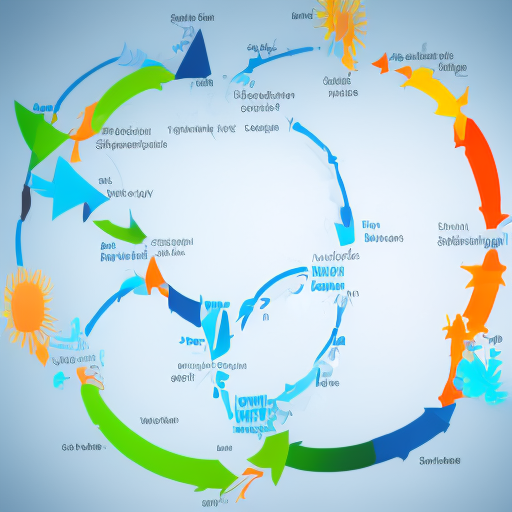

In [20]:
with torch.no_grad():
    image = pipe(
        prompt,
        negative_prompt="",
        num_inference_steps=50,
        guidance_scale=7.0,
    ).images[0]
image

In [ ]:
token_vocab_size = 49408 #CLIPTextModel
compressor_chpt = r"C:\COMP9800\model_checkpoints\compressor\compressor_weight_400E.pt"

comp_state_dict = torch.load(compressor_chpt, map_location=device)

compressor = TokenCompressor(max_text_token_size, token_vocab_size)

compressor.load_state_dict(comp_state_dict)

ft_unet = UNet2DConditionModel.from_pretrained(
    check_point, subfolder="unet"
)

model = MedQATTIModel(tokenizer, vae, text_encoder, ft_unet, 
                        noise_scheduler, torch.float32, 
                        train_text_encoder,compressor)



In [ ]:
image_norm = model.infer(prompt, 50, 7.0)

Prompt is compressed to fit the Unet.


C:\Users\50183\AppData\Local\Temp\ipykernel_54840\4047094098.py:78: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (batch_size, self.unet.in_channels, 64, 64),


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
image = (image_norm / 2 + 0.5).clamp(0, 1)
image = image * 255
image = image.to(torch.uint8)

In [ ]:
image.shape

torch.Size([1, 3, 512, 512])

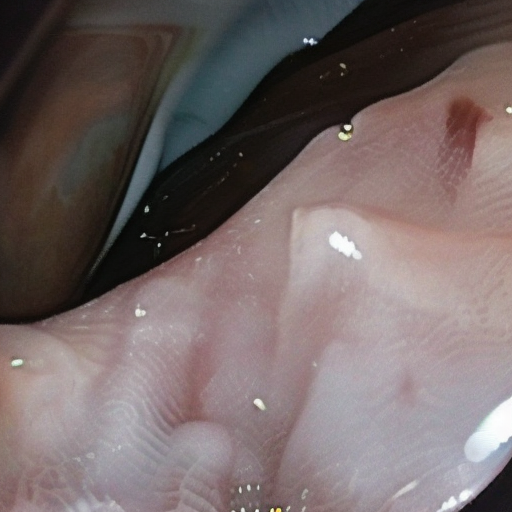

In [ ]:
to_pil = transforms.ToPILImage()
to_pil(image.squeeze(0))

# Explore Diagram Dataset

In [ ]:
import json

ai2d_caption_gpt4 = r'C:\COMP9800\Dataset\AI2D-Caption\ai2d_caption_gpt4v.json'

with open(ai2d_caption_gpt4,'r') as f:
    captions = json.load(f)
image_captions=[]
no_cap_image=[]
for cap in captions:
    if 'caption' not in cap:
        no_cap_image.append(cap['image'])
        continue
    image_captions.append({'img':cap['image'], 'caption':cap['caption']})

In [ ]:
[img for img in image_captions if img['img'] == '1042.png']

[{'img': '1042.png',
  'caption': "A diagram showing Earth's position in relation to the Sun during different seasons and equinoxes."}]

C:\Users\50183\AppData\Local\Temp\ipykernel_54840\2395985039.py:3: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_size'.
  tokenizer, vae.sample_size)


In [ ]:
loss_hist = training_function(text_encoder, vae, unet, diagram_train_dataloader)

Available Device: cpu
total btach size: 4
***** Running training *****
  Num examples = 4898
  Instantaneous batch size per device = 2
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 2
  Total optimization steps = 1


  0%|          | 0/1 [00:00<?, ?it/s]